In [1]:
# Behzad Ghabaei
# CS 82A - Data Science
# module 4 Lab 1 - Describe and Correlate
# module4_lab.ipynb
# Instructor Seno
# 9/22/2026

## Step 1: Load your clean data

#### Load sales_clean.csv and confirm its shape matches what you saved in Lab 3.  You should see: (292, 6) 

In [2]:
import pandas as pd
df = pd.read_csv("sales_clean.csv")
df.shape

(292, 6)

## Step 2: Center and spread of price and qty
#### Compute mean, median, and standard deviation for price and for qty (Tutorial 1 pattern).  You should see: six numbers. The price mean sits noticeably above the price median; that gap is seeded skew.

In [3]:
print("price mean: ", df["price"].mean())
print("price median: ", df["price"].median())
print("price std: ", df["price"].std())
print("-" * 10)
print("qty mean: ", df["qty"].mean())
print("qty median: ", df["qty"].median())
print("qty std: ", df["qty"].std())

price mean:  55.52315068493151
price median:  37.53
price std:  71.76708493504132
----------
qty mean:  2.9863013698630136
qty median:  3.0
qty std:  1.4092785381929205


## Step 3: Which summary would you report? (markdown cell)

#### Which of mean or median would you report for price, and why? 2–3 sentences.

#### Remembering our Cleaning Log from module3_lab2 recall imputing for price vales at 37.53.  Since the price standard deviation is such a large amount, at 71.76, I would prefer the median, and inspect the mean for outstanding outliers. For example 479.29 is a large sum from "price" listed as the max and which is pulling the mean up, this is for expensive electronic equiptment in quantity.  When we take a look at the prices that carry weight, we notice that the merchandise is a mixture of very different items of value, for example, we're comparing the prices of pen and paper, vs. cameras and monitors, so there is going to be a significant difference, but these outliers are really important for inventory reference and loss prevention. It's important to keep the highly priced items accounted for, but lower priced items are not that important, since these things are pens, paper, and mugs.  The min at 2.93 is listed as 4 notebooks, but we used the median at 37.53 to fill empty values, which explains the single notebook for 37.53, which is high.  So rather than filling in the missing values by hand, these imputed price values were given 37.53.

In [4]:
df.describe()

,order_id,price,qty,zip
count,292.000000,292.000000,292.000000,292.000000
mean,1145.500000,55.523151,2.986301,45463.989726
std,84.437354,71.767085,1.409279,39284.386854
min,1000.000000,2.930000,1.000000,2116.000000
25%,1072.750000,11.045000,2.000000,2134.000000
50%,1145.500000,37.530000,3.000000,30303.000000
75%,1218.250000,55.510000,4.000000,90210.000000
max,1291.000000,479.290000,5.000000,98101.000000


#### These prices were imputed.

In [5]:
df [df["price"] == 37.53]


,order_id,date,product,price,qty,zip
3,1066,2026-05-30,notebook,37.53,1,98101
5,1280,2026-04-22,pen set,37.53,4,30303
30,1088,2026-04-28,pen set,37.53,2,2134
44,1101,2026-05-12,keyboard,37.53,3,2116
49,1199,2026-04-18,charger,37.53,5,30303
50,1018,2026-05-04,monitor,37.53,4,10001
55,1170,2026-04-04,monitor,37.53,1,2116
91,1040,2026-05-08,pen set,37.53,3,2134
103,1240,2026-04-16,headphones,37.53,1,60614
127,1261,2026-05-09,desk lamp,37.53,2,90405


#### This was the max expensive priced item, a computer monitor, quantity 1.

In [6]:
df[ df["price"] == 479.29]

,order_id,date,product,price,qty,zip
221,1093,2026-04-14,monitor,479.29,1,90210


#### This was the min priced item, notebook, quantity 4.

In [7]:
df[ df["price"] == 2.93 ]

,order_id,date,product,price,qty,zip
89,1069,2026-04-18,notebook,2.93,4,60614


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    str    
 2   product   292 non-null    str    
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 13.8 KB


In [9]:
df.shape

(292, 6)

In [10]:
df.head()

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


## Step 4: Histogram of price

#### Plot a histogram of price with about 20 bins (Tutorial 2) and, in a markdown line, name its shape.  You should see: a right-skewed histogram: most prices low, a tail of expensive items.

<Axes: ylabel='Frequency'>

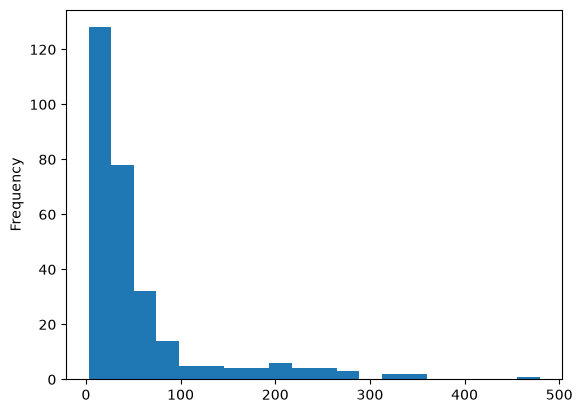

In [11]:
df["price"].plot(kind="hist", bins=20)

#### The histogram shows a skewed right tail, with the bulk on the left, this signifies the mean is above the median. The lack of symmetry, is called a positive skew.  The skew favors the median. Expensive items have low frequency price around 500, and inexpensive items have high frequency, less than 100 frequently appears.

## Step 5: Create the revenue column
#### Make revenue = price * qty as a new column (Tutorial 3 pattern).  You should see: a 7th column appears in df.head().

#### The revenue column is useful to see how the quantity can change the actual revenue due to the price. 

In [12]:
df["revenue"] = df["price"] * df["qty"]
df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


## Step 6: Correlation matrix
#### Compute the correlation matrix of the numeric columns (Tutorial 4). Note the strongest off-diagonal value.  You should see: a matrix; qty vs. revenue should be the standout.

In [13]:
df.corr(numeric_only=True)

,order_id,price,qty,zip,revenue
order_id,1.000000,-0.005070,0.031420,-0.014784,0.004181
price,-0.005070,1.000000,-0.041982,0.023812,0.821001
qty,0.031420,-0.041982,1.000000,0.086869,0.312793
zip,-0.014784,0.023812,0.086869,1.000000,0.047090
revenue,0.004181,0.821001,0.312793,0.047090,1.000000


#### Pearson's r, measures how closely two variables follow a straight line relationship. It always falls between -1 and +1.  Positive means they rise together, and negative means, as one rises the other falls.  Zero means no relationship at all.  The values near 1 or -1 mean that they are close to a straight line.  Values near 0 form a shapeless cloud.  For example, 0.1 is weak, 0.3 is moderate, and above 0.5 is strong (negative also).  If there was a curved perfect relationship, the r could be very low.  Correlations describe that changes in one variable are associated by another.  However with correlations just because 2 things appear to have a strong linear relationship, doesn't mean they are related. Such as spurious correlations, that appear to be related but are not directly, but a regression is a functional relationship.  Predictable analytics that provide actionable insights require logical and accurate datasets. From our lab, a correlation of 0.31 is a weak positive link, between qty and revenue, and a strong positive relationship between price and revenue is r = .82. The other values are not really related to economics, like zip and id, and indicate no relationship. There seems to be a strong linear relationship between **price increase and revenue production**, an even higher correlation than between **quantity and revenue**, which is at .31, a moderate or even low, poorly related correlation.
#### -.005 indicates no relationship
#### .031  indicates no relationship
#### -.0149  indicates no relationship
#### .0041  indicates no relationship
#### .086  indicates no relationship
#### .312  indicates weak or moderate relationship
#### -.014  indicates no relationship
#### .023  indicates no relationship
#### .047  indicates no relationship
#### .821  indicates **strong** linear positive relationship. (remarkable)

In [14]:
df["qty"].corr(df["revenue"]) 

np.float64(0.3127930967032907)

#### I noticed the diagonal value at 1.0 and the qty and revenue correlation at .3127, which is a weak positive linear relationship, The strong relationship is between price and revenue.

## Step 7: Scatter to verify
#### Scatter-plot qty against revenue (Tutorial 5) and check the cloud agrees with the r value.  You should see: an upward-drifting cloud.

In [ ]:
df.plot.scatter(x="qty", y="revenue")

<Axes: xlabel='qty', ylabel='revenue'>

### The upward drifting cloud represents the revenue increasing as the quantity increases slightly. It verifies that there is a weak relationship between revenue and quantity.

#### By comparison the correlation of price and revenue is strong at .82 , scatter plot indicates below.

In [ ]:
df["price"].corr(df["revenue"]) 

In [ ]:
df.plot.scatter(x="price", y="revenue")

## Step 8: The analyst’s sentence (markdown cell)
#### One plain-English claim: the relationship, its strength, and one caution (a confounder or outlier risk). This is the deliverable that matters most.

#### The conclusion is that expensive items are the reason behind large revenue results.  There is a weak positive correlation between qty and revenue. The r describes the relationship between the two.  **The r= .3127, between qty and revenue** is low, but a remarkable correlation occurs between **price and revenue the r = .82**, considerably higher and better.  The correlations with very small values signify that the two variables don't work together, such as qty and price.  Negative values approaching -1 are also a strong correlation, for example -.9 indicates strong negative correlation.

#### These correlation values may reflect that care is not taken, by making cheap priced items, purchased in bulk and expensive purchased items purchased one at a time.  The other values like zip and id were not as helpful to use as price, quantity, and reveue.  What to say to the manager is that the data shows a **strong positive relationship between price and revenue (r = 0.821)**, this means that total revenue is related to item price but not quantity, and there are a few highly priced outliers that may skew the metrics.

#### Another point is that if the 12 items could have been filled individually by hand, would this result in more accurate correlations? If the values could have been inserted differently with more careful prices, the correlation betweeb qty and revenue would change, for example to r= .2785. But the correlation between price and revenue would be around at r=.8688. This could show us that accurate insertions would have gotten different results with a slighly higher correlation between price and revenue. Imputing with the median is a good way of balancing the dataset with empty data points, without having to fill each missing price individually.¶ It seems convenient and accurate when comparing .82 vs .86.

###### Here is the hand insertion sample 
###### df.loc[3, "price" ] = 6.00
###### df.loc[5, "price" ] = 30.00
###### df.loc[30, "price" ] = 15.00
###### df.loc[44, "price" ] = 112.59
###### df.loc[49, "price" ] = 187.65
###### df.loc[50, "price" ] = 800.00
###### df.loc[55, "price" ] = 200.00
###### df.loc[91, "price" ] = 37.53
###### df.loc[103, "price" ] = 37.53
###### df.loc[127, "price" ] = 80.00
###### df.loc[176, "price" ] = 200.00
###### df.loc[245, "price" ] = 37.53

## Step 9: By-hand check
#### In a markdown cell, compute the mean and median of [2, 4, 4, 6, 9] by hand, then verify both with Python.  You should see: mean 5.0, median 4, in both places.

#### For the mean calculate the average by adding all the numbers and dividing by the count, for median sort the numbers and take the one in the middle.

#### The mean is (2 + 4 + 4 + 6 + 9) / 5 = 5
#### The median is 1=**2**, 2=**4**, 3=**4** , 4=**6**, 5=**9**, then after sorting, the central number is index 3=**4.0**

In [ ]:
my_list = [2, 4, 4, 6, 9]
df_2 = pd.DataFrame(my_list)
print("mean of my_list: ", df_2.mean())
print("median of my_list: ", df_2.median())

#### Behzad Ghabaei - End Of Lab